# Data Merging: Tesla Stock Data, Web Scraping News and REST API News

In this notebook, the cleaned Tesla stock data is combined with two news datasets:

1. Tesla stock prices from a CSV file
2. Tesla-related news from web scraping
3. Tesla-related news from the Alpha Vantage REST API

The goal is to create one combined dataset for the story: **How do Tesla-related news volume and sentiment appear around the available Tesla stock data?**

Important implementation choice: the final merge uses an **outer date spine**. This keeps newer news days even when the local stock CSV does not yet contain matching market prices. This is important because otherwise the REST API data would disappear from the final result when the stock data ends earlier than the news data.

# 2. Imports

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 3. Load Data

In [ ]:
stock_df = pd.read_csv("../data/processed/tesla_stock_data_cleaned.csv")
scraped_news_df = pd.read_csv("../data/processed/tesla_news_cleaned.csv")
api_news_df = pd.read_csv("../data/processed/alpha_vantage_tesla_news_cleaned.csv")

print("Stock data:", stock_df.shape)
print("Scraped news data:", scraped_news_df.shape)
print("API news data:", api_news_df.shape)

display(stock_df.head())
display(scraped_news_df.head())
display(api_news_df.head())

Stock data: (1588, 10)
Scraped news data: (101, 5)
API news data: (50, 11)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100
0,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455,NaN,1.1387,NaN,NaN
1,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485,0.019256,0.7707,NaN,NaN
2,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070,0.038801,1.2183,NaN,NaN
3,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895,0.049203,2.0180,NaN,NaN
4,2020-01-09,33.1400,33.2533,31.5247,32.0893,426947790,-0.021945,1.7286,NaN,NaN


,title,link,published_at,source,date
0,Tesla Is Worth More Than The Next 10 Car Compa...,https://news.google.com/rss/articles/CBMikwFBV...,2026-06-11 16:26:35+00:00,Yahoo Finance,2026-06-11
1,Tesla Is Worth More Than The Next 10 Car Compa...,https://news.google.com/rss/articles/CBMipgFBV...,2026-06-11 16:26:35+00:00,24/7 Wall St.,2026-06-11
2,Musk’s Net Worth Down More Than $50 Billion Ah...,https://news.google.com/rss/articles/CBMizwFBV...,2026-06-11 16:24:14+00:00,Forbes,2026-06-11
3,Is It Time to Buy Rivian Stock as R2 Deliverie...,https://news.google.com/rss/articles/CBMimAFBV...,2026-06-11 16:23:20+00:00,The Motley Fool,2026-06-11
4,How Tesla’s Stock Listing in 2010 Enabled Spac...,https://news.google.com/rss/articles/CBMigAFBV...,2026-06-11 15:15:44+00:00,The New York Times,2026-06-11


,title,url,time_published,summary,source,overall_sentiment_score,overall_sentiment_label,tsla_relevance_score,tsla_sentiment_score,tsla_sentiment_label,date
0,UBS reiterates Packaging Corp. of America stoc...,https://ca.investing.com/news/stock-market-new...,2026-06-11 14:38:29,UBS has reiterated a Buy rating and a $248.00 ...,Investing.com Canada,0.049732,Neutral,0.570210,0.321158,Somewhat-Bullish,2026-06-11
1,Oppenheimer raises Tesla stock price target on...,https://www.investing.com/news/analyst-ratings...,2026-06-11 13:25:40,Oppenheimer has increased its price target for...,Investing.com,0.203912,Somewhat-Bullish,1.000000,0.463278,Bullish,2026-06-11
2,Is the 2026 Toyota bZ Woodland a Good Crossove...,https://www.cars.com/articles/is-the-2026-toyo...,2026-06-11 11:39:09,The 2026 Toyota bZ Woodland is an electric cro...,Cars.com,0.037104,Neutral,0.639476,0.040831,Neutral,2026-06-11
3,"General Motors pivots battery strategy, puts L...",https://seekingalpha.com/news/4602466-general-...,2026-06-11 09:27:02,General Motors is reportedly shifting its elec...,Seeking Alpha,0.138295,Neutral,0.644370,0.171347,Somewhat-Bullish,2026-06-11
4,Musk to discuss Terafab chip plant plans at AS...,https://seekingalpha.com/news/4602459-musk-to-...,2026-06-11 08:10:40,Elon Musk is scheduled to virtually attend ASM...,Seeking Alpha,0.172115,Somewhat-Bullish,0.836416,0.208840,Somewhat-Bullish,2026-06-11


# 4. Convert Date Columns

In [ ]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
scraped_news_df["date"] = pd.to_datetime(scraped_news_df["date"])
api_news_df["date"] = pd.to_datetime(api_news_df["date"])

print("Stock date range:", stock_df["Date"].min(), "to", stock_df["Date"].max())
print("Scraped news date range:", scraped_news_df["date"].min(), "to", scraped_news_df["date"].max())
print("API news date range:", api_news_df["date"].min(), "to", api_news_df["date"].max())

Stock date range: 2020-01-03 00:00:00 to 2026-04-29 00:00:00
Scraped news date range: 2026-04-06 00:00:00 to 2026-06-11 00:00:00
API news date range: 2026-06-09 00:00:00 to 2026-06-11 00:00:00


# 5. Aggregate Web Scraping News per Day

In [ ]:
scraped_daily = scraped_news_df.groupby("date").agg(
    scraped_news_count=("title", "count"),
    scraped_sources=("source", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    scraped_titles=("title", lambda x: " | ".join(x.dropna().astype(str).head(3)))
).reset_index()

display(scraped_daily.head())

,date,scraped_news_count,scraped_sources,scraped_titles
0,2026-04-06,1,Yahoo Finance,Why JPMorgan is warning Tesla stock may crash ...
1,2026-04-16,1,Morningstar,"Ahead of Earnings, Is Tesla Stock a Buy, a Sel..."
2,2026-04-18,1,Yahoo Finance,Tesla stock snaps 8-week losing streak with ea...
3,2026-04-23,1,Morningstar,Tesla Earnings: Shares Fall Slightly as Manage...
4,2026-04-30,1,Morningstar,"After Earnings, Is Tesla Stock a Buy, a Sell, ..."


# 6. Aggregate REST API News per Day

In [ ]:
api_daily = api_news_df.groupby("date").agg(
    api_news_count=("title", "count"),
    avg_api_sentiment=("overall_sentiment_score", "mean"),
    avg_tsla_sentiment=("tsla_sentiment_score", "mean"),
    avg_tsla_relevance=("tsla_relevance_score", "mean"),
    api_sentiment_labels=("overall_sentiment_label", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    tsla_sentiment_labels=("tsla_sentiment_label", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    api_titles=("title", lambda x: " | ".join(x.dropna().astype(str).head(3)))
).reset_index()

api_daily.head()

,date,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles
0,2026-06-09,19,0.113681,0.060044,0.732597,"Bullish, Neutral, Somewhat-Bearish, Somewhat-B...","Bearish, Bullish, Neutral, Somewhat-Bearish, S...","[Form 4] Tesla, Inc. Insider Trading Activity ..."
1,2026-06-10,22,0.033082,0.039781,0.699602,"Bearish, Neutral, Somewhat-Bearish, Somewhat-B...","Bearish, Neutral, Somewhat-Bearish, Somewhat-B...","Sylebra Capital LLC, an Impinj director, sells..."
2,2026-06-11,9,0.133557,0.206554,0.759403,"Neutral, Somewhat-Bullish","Bullish, Neutral, Somewhat-Bearish, Somewhat-B...",UBS reiterates Packaging Corp. of America stoc...


# 7. Create Date Spine for News Period

In [ ]:
min_news_date = min(scraped_news_df["date"].min(), api_news_df["date"].min())
max_news_date = max(scraped_news_df["date"].max(), api_news_df["date"].max())

all_dates = pd.DataFrame({
    "Date": sorted(
        set(stock_df["Date"]) |
        set(scraped_daily["date"]) |
        set(api_daily["date"])
    )
})

all_dates = all_dates[
    (all_dates["Date"] >= min_news_date) &
    (all_dates["Date"] <= max_news_date)
].copy()

print("News date range:", min_news_date, "to", max_news_date)
print("Date spine rows:", all_dates.shape[0])
print("Stock rows in this period:", stock_df[(stock_df["Date"] >= min_news_date) & (stock_df["Date"] <= max_news_date)].shape[0])

News date range: 2026-04-06 00:00:00 to 2026-06-11 00:00:00
Date spine rows: 40
Stock rows in this period: 18


# 8. Merge All Data

In [ ]:
merged_df = all_dates.merge(stock_df, on="Date", how="left")

merged_df = merged_df.merge(
    scraped_daily.rename(columns={"date": "Date"}),
    on="Date",
    how="left"
)

merged_df = merged_df.merge(
    api_daily.rename(columns={"date": "Date"}),
    on="Date",
    how="left"
)

print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (40, 20)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,scraped_news_count,scraped_sources,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles
0,2026-04-06,362.590,367.72,346.64,352.82,77697643.0,-0.021548,21.08,389.155543,421.931363,1.0,Yahoo Finance,Why JPMorgan is warning Tesla stock may crash ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-07,346.440,348.02,337.24,346.65,74515355.0,-0.017488,10.78,387.382877,420.945563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-08,363.790,364.50,339.67,343.25,78838616.0,-0.009808,24.83,385.178543,419.981863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-09,343.150,348.88,337.25,345.62,62164016.0,0.006905,11.63,382.785877,419.132063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-10,346.285,350.36,342.74,348.95,51336034.0,0.009635,7.62,380.798210,418.601663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 9. Fill Missing Values and Add Flags

In [ ]:
for count_col in ["scraped_news_count", "api_news_count"]:
    merged_df[count_col] = merged_df[count_col].fillna(0).astype(int)

for sentiment_col in ["avg_api_sentiment", "avg_tsla_sentiment", "avg_tsla_relevance"]:
    merged_df[sentiment_col] = merged_df[sentiment_col].fillna(0)

text_columns = [
    "scraped_sources",
    "scraped_titles",
    "api_sentiment_labels",
    "tsla_sentiment_labels",
    "api_titles"
]

for column in text_columns:
    merged_df[column] = merged_df[column].fillna("")

merged_df["has_stock_data"] = merged_df["Close"].notna()
merged_df["total_news_count"] = merged_df["scraped_news_count"] + merged_df["api_news_count"]

print("Rows with stock data:", merged_df["has_stock_data"].sum())
print("Rows with scraped news:", (merged_df["scraped_news_count"] > 0).sum())
print("Rows with REST API news:", (merged_df["api_news_count"] > 0).sum())
print("Total scraped news:", merged_df["scraped_news_count"].sum())
print("Total API news:", merged_df["api_news_count"].sum())

merged_df.head()

Rows with stock data: 18
Rows with scraped news: 25
Rows with REST API news: 3
Total scraped news: 101
Total API news: 50


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,scraped_news_count,scraped_sources,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles,has_stock_data,total_news_count
0,2026-04-06,362.590,367.72,346.64,352.82,77697643.0,-0.021548,21.08,389.155543,421.931363,1,Yahoo Finance,Why JPMorgan is warning Tesla stock may crash ...,0,0.0,0.0,0.0,,,,True,1
1,2026-04-07,346.440,348.02,337.24,346.65,74515355.0,-0.017488,10.78,387.382877,420.945563,0,,,0,0.0,0.0,0.0,,,,True,0
2,2026-04-08,363.790,364.50,339.67,343.25,78838616.0,-0.009808,24.83,385.178543,419.981863,0,,,0,0.0,0.0,0.0,,,,True,0
3,2026-04-09,343.150,348.88,337.25,345.62,62164016.0,0.006905,11.63,382.785877,419.132063,0,,,0,0.0,0.0,0.0,,,,True,0
4,2026-04-10,346.285,350.36,342.74,348.95,51336034.0,0.009635,7.62,380.798210,418.601663,0,,,0,0.0,0.0,0.0,,,,True,0


# 10. Save Merged Dataset

In [ ]:
os.makedirs("../data/results", exist_ok=True)

merged_df.to_csv("../data/results/tesla_stock_news_merged.csv", index=False)

print("Saved merged data to ../data/results/tesla_stock_news_merged.csv")
print("Final shape:", merged_df.shape)

Saved merged data to ../data/results/tesla_stock_news_merged.csv
Final shape: (40, 22)


# 11. Quick Check

In [ ]:
check_df = pd.read_csv("../data/results/tesla_stock_news_merged.csv")

print("File loaded successfully.")
print("Rows:", len(check_df))
print("Columns:", list(check_df.columns))

display(check_df.head())

File loaded successfully.
Rows: 40
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'MA_30', 'MA_100', 'scraped_news_count', 'scraped_sources', 'scraped_titles', 'api_news_count', 'avg_api_sentiment', 'avg_tsla_sentiment', 'avg_tsla_relevance', 'api_sentiment_labels', 'tsla_sentiment_labels', 'api_titles', 'has_stock_data', 'total_news_count']


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,scraped_news_count,scraped_sources,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles,has_stock_data,total_news_count
0,2026-04-06,362.590,367.72,346.64,352.82,77697643.0,-0.021548,21.08,389.155543,421.931363,1,Yahoo Finance,Why JPMorgan is warning Tesla stock may crash ...,0,0.0,0.0,0.0,NaN,NaN,NaN,True,1
1,2026-04-07,346.440,348.02,337.24,346.65,74515355.0,-0.017488,10.78,387.382877,420.945563,0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,True,0
2,2026-04-08,363.790,364.50,339.67,343.25,78838616.0,-0.009808,24.83,385.178543,419.981863,0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,True,0
3,2026-04-09,343.150,348.88,337.25,345.62,62164016.0,0.006905,11.63,382.785877,419.132063,0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,True,0
4,2026-04-10,346.285,350.36,342.74,348.95,51336034.0,0.009635,7.62,380.798210,418.601663,0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,True,0


# 12. Visualization: News Count vs Daily Return

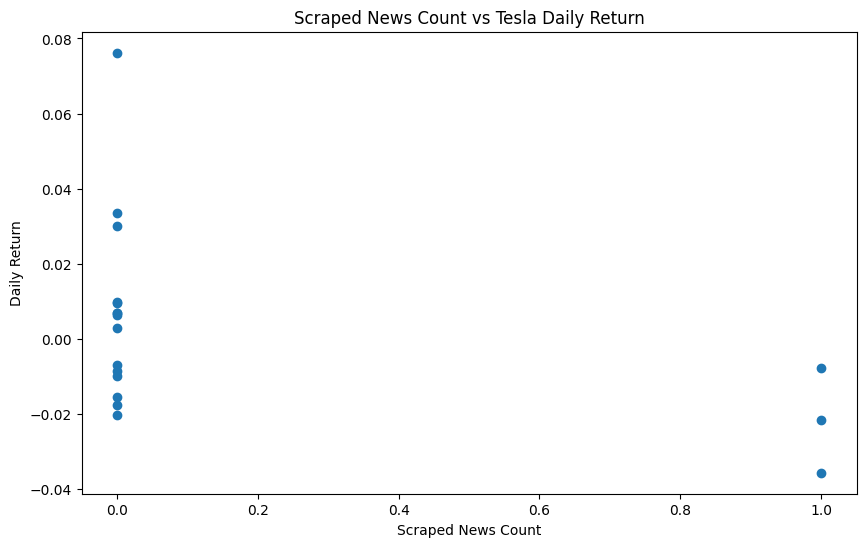

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["scraped_news_count"], merged_df["Daily_Return"])
plt.title("Scraped News Count vs Tesla Daily Return")
plt.xlabel("Scraped News Count")
plt.ylabel("Daily Return")
plt.show()

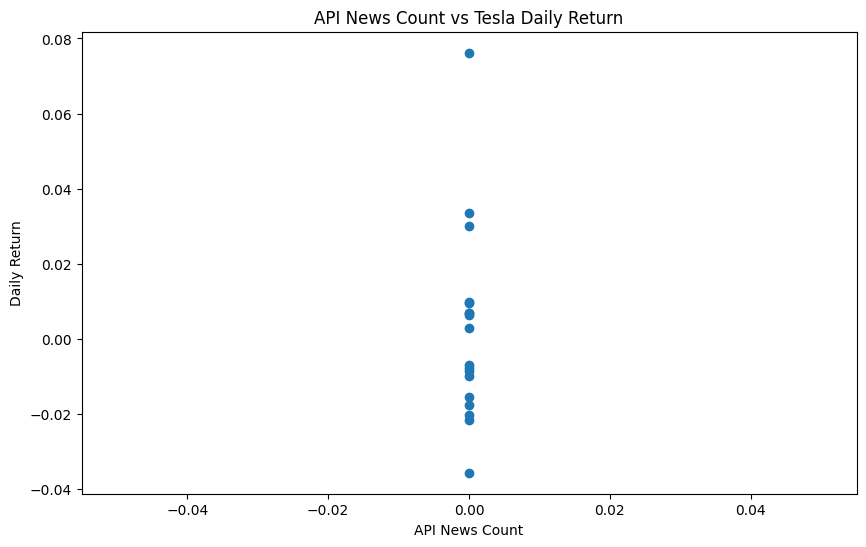

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["api_news_count"], merged_df["Daily_Return"])
plt.title("API News Count vs Tesla Daily Return")
plt.xlabel("API News Count")
plt.ylabel("Daily Return")
plt.show()

# 13. Visualization: Sentiment vs Daily Return

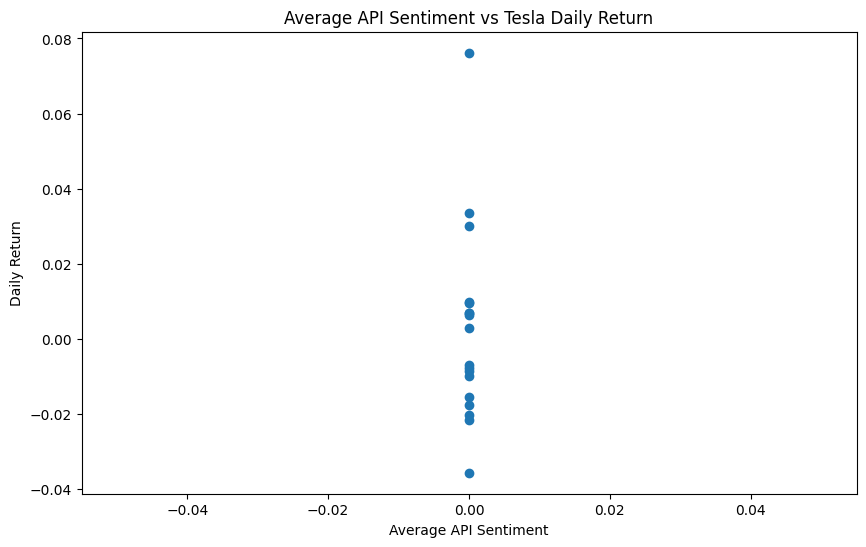

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["avg_api_sentiment"], merged_df["Daily_Return"])
plt.title("Average API Sentiment vs Tesla Daily Return")
plt.xlabel("Average API Sentiment")
plt.ylabel("Daily Return")
plt.show()

# 14. Correlation

In [ ]:
print("Correlation scraped news count vs daily return:")
print(merged_df["scraped_news_count"].corr(merged_df["Daily_Return"]))

print("\nCorrelation API news count vs daily return:")
print(merged_df["api_news_count"].corr(merged_df["Daily_Return"]))

print("\nCorrelation API sentiment vs daily return:")
print(merged_df["avg_api_sentiment"].corr(merged_df["Daily_Return"]))

Correlation scraped news count vs daily return:
-0.429432006566878

Correlation API news count vs daily return:
nan

Correlation API sentiment vs daily return:
nan


/opt/pyvenv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/pyvenv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# 15. Short Conclusion

# 15. Short Conclusion

The final merged dataset keeps all relevant dates from the stock file, web scraping source and REST API source. This is important because the local Tesla stock CSV ends earlier than the newest news records. The `has_stock_data` column shows which rows have market data, while `scraped_news_count`, `api_news_count`, `avg_tsla_sentiment` and `total_news_count` preserve the news story for later Kafka and Spark processing.